# ANI

In [1]:
import pandas as pd

ruta_archivo = "/home/haydeeperuyero/FastANI/miel_ani_aai_caai/fastani_Miel.all.v3.ani"

# Lread file to a Dataframe
df = pd.read_csv(ruta_archivo, sep="\t", header=None)


In [2]:
# Add colnames
df.columns = ["query", "reference", "ani", "cbfm", "tqf"]
df

,query,reference,ani,cbfm,tqf
0,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,100.0000,572,572
1,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,/home/haydeeperuyero/FastANI/data_v2/41_Melli_...,99.7828,544,572
2,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,/home/haydeeperuyero/FastANI/data_v2/barcode04...,99.7450,553,572
3,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,/home/haydeeperuyero/FastANI/data_v2/45_Melli_...,99.7444,561,572
4,/home/haydeeperuyero/FastANI/data_v2/22_Melli_...,/home/haydeeperuyero/FastANI/data_v2/barcode03...,99.7249,547,572
...,...,...,...,...,...
235,/home/haydeeperuyero/FastANI/data_v2/barcode20...,/home/haydeeperuyero/FastANI/data_v2/Lactobaci...,80.8399,233,472
236,/home/haydeeperuyero/FastANI/data_v2/barcode20...,/home/haydeeperuyero/FastANI/data_v2/Nicoliell...,80.8333,220,472
237,/home/haydeeperuyero/FastANI/data_v2/barcode20...,/home/haydeeperuyero/FastANI/data_v2/46_Melli_...,78.4828,101,472
238,/home/haydeeperuyero/FastANI/data_v2/barcode20...,/home/haydeeperuyero/FastANI/data_v2/45_Melli_...,78.2845,103,472


In [3]:
import os 
def limpiar_nombre(ruta):
    nombre = os.path.basename(ruta)  # Obtiene solo el nombre del archivo
    return nombre.replace(".fna", "")  # Elimina la extensión .fna

# Aplicar la función a las dos primeras columnas
df.iloc[:, 0] = df.iloc[:, 0].apply(limpiar_nombre)
df.iloc[:, 1] = df.iloc[:, 1].apply(limpiar_nombre)

df

,query,reference,ani,cbfm,tqf
0,22_Melli_029,22_Melli_029,100.0000,572,572
1,22_Melli_029,41_Melli_001,99.7828,544,572
2,22_Melli_029,barcode04,99.7450,553,572
3,22_Melli_029,45_Melli_020,99.7444,561,572
4,22_Melli_029,barcode03,99.7249,547,572
...,...,...,...,...,...
235,barcode20,Lactobacillus_Sy-1,80.8399,233,472
236,barcode20,Nicoliella_spurrieriana_SGEP1_A5,80.8333,220,472
237,barcode20,46_Melli_022,78.4828,101,472
238,barcode20,45_Melli_016,78.2845,103,472


In [4]:
# Obtain unique IDs for query and reference 
ids_unicos = pd.unique(df[['query', 'reference']].values.ravel())

# Create an empty DataFrame with the unique IDs as colnames and rownames, start at 0
matriz_ani = pd.DataFrame(0, index=ids_unicos, columns=ids_unicos)

# Fill the matrix with the ani values
for _, row in df.iterrows():
    matriz_ani.at[row['query'], row['reference']] = row['ani']

/tmp/ipykernel_2008283/2927355355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.7828' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_ani.at[row['query'], row['reference']] = row['ani']
/tmp/ipykernel_2008283/2927355355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.745' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_ani.at[row['query'], row['reference']] = row['ani']
/tmp/ipykernel_2008283/2927355355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.7444' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matriz_ani.at[row['query'], row['reference']] = row['ani']
/tmp/ipykernel_2008283/

In [5]:
# Show the matrix
matriz_ani

,22_Melli_029,41_Melli_001,barcode04,45_Melli_020,barcode03,47_Melli_001,barcode20,45_Melli_016,46_Melli_022,Nicoliella_lavandulae_Es01,...,92_Scapto_002,42_Melli_004,92_Scapto_009,51_Scapto_004,90_Scapto_012,89_Scapto_002,Acetilactobacillus_jinshanensis_aerogenes_strain_Sichuan_bran_vinegar,Acetilactobacillus_jinshanensis_strain_HSLZ-75,Acetilactobacillus_jinshanensis_brasiliensis,Apilactobacillus_kunkeei
22_Melli_029,100.0000,99.7828,99.7450,99.7444,99.7249,99.6494,84.8636,83.1864,83.0708,80.4878,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
41_Melli_001,99.7662,100.0000,99.7133,99.7851,99.6239,99.7156,84.8223,82.3080,82.4589,80.3954,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
barcode04,99.6685,99.6418,100.0000,99.6017,99.5421,99.4356,84.8051,83.1724,83.0526,80.6533,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
45_Melli_020,99.7299,99.8077,99.6705,100.0000,99.6112,99.7830,84.7441,82.8757,82.9026,80.3520,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
barcode03,99.6832,99.5963,99.4987,99.5167,100.0000,99.4218,85.0489,83.4355,83.3880,80.7820,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
47_Melli_001,99.6902,99.7880,99.6407,99.8326,99.5022,100.0000,84.6167,82.5689,82.4735,80.1869,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
barcode20,84.8293,84.8752,85.1486,84.6527,85.0694,84.6086,100.0000,78.2845,78.4828,81.3750,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
45_Melli_016,82.8813,82.9833,83.4739,83.1440,83.4765,82.9597,78.4465,100.0000,99.9173,78.2008,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
46_Melli_022,82.6388,82.8931,83.4024,82.9602,83.2497,83.2010,78.4451,99.9298,100.0000,78.1322,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
Nicoliella_lavandulae_Es01,80.5272,80.4871,80.6610,80.5298,80.8990,80.3065,81.4887,78.0316,78.0433,100.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


In [6]:
matriz_ani.index

Index(['22_Melli_029', '41_Melli_001', 'barcode04', '45_Melli_020',
       'barcode03', '47_Melli_001', 'barcode20', '45_Melli_016',
       '46_Melli_022', 'Nicoliella_lavandulae_Es01', 'Lactobacillus_Sy-1',
       'Nicoliella_spurrieriana_SGEP1_A5', '40_Melli_029', '23_Scapto_001',
       '89_Scapto_001', '92_Scapto_002', '42_Melli_004', '92_Scapto_009',
       '51_Scapto_004', '90_Scapto_012', '89_Scapto_002',
       'Acetilactobacillus_jinshanensis_aerogenes_strain_Sichuan_bran_vinegar',
       'Acetilactobacillus_jinshanensis_strain_HSLZ-75',
       'Acetilactobacillus_jinshanensis_brasiliensis',
       'Apilactobacillus_kunkeei'],
      dtype='object')

In [7]:
orden = ['40_Melli_029', '45_Melli_016', '46_Melli_022', 
         'Lactobacillus_Sy-1',
         'Nicoliella_spurrieriana_SGEP1_A5', 'Nicoliella_lavandulae_Es01',
         '22_Melli_029','barcode03', '45_Melli_020','47_Melli_001','barcode04','41_Melli_001','barcode20',
         'Acetilactobacillus_jinshanensis_brasiliensis',
         'Acetilactobacillus_jinshanensis_strain_HSLZ-75',
         'Acetilactobacillus_jinshanensis_aerogenes_strain_Sichuan_bran_vinegar', 
         '51_Scapto_004','89_Scapto_002','90_Scapto_012','92_Scapto_009',
         '42_Melli_004','23_Scapto_001', '89_Scapto_001','92_Scapto_002',
         'Apilactobacillus_kunkeei']
          
matriz_ani = matriz_ani.reindex(index=orden, columns=orden)
       
  
       

In [8]:
rename_dict = {
    '40_Melli_029':'40_Melli.029', 
    '45_Melli_016':'45_Melli.016', 
    '46_Melli_022':'46_Melli.022',
    'Lactobacillus_Sy-1':'Lactobacillus sp. Sy-1',
    'Nicoliella_spurrieriana_SGEP1_A5': 'N. spurrieriana SGEP1_A5', 
    'Nicoliella_lavandulae_Es01': 'N. lavandulae Es01',
    '22_Melli_029':'22_Melli.029',
    'barcode03':'40_Melli_barcode03', 
    '45_Melli_020':'45_Melli.020',
    '47_Melli_001':'47_Melli.001',
    'barcode04':'39_Melli_barcode04',
    '41_Melli_001':'41_Melli.001',
    'barcode20':'90_Scapto_barcode20',
    'Acetilactobacillus_jinshanensis_brasiliensis':'A. jinshanensis brasiliensis',
    'Acetilactobacillus_jinshanensis_strain_HSLZ-75':'A. jinshanensis strain HSLZ-75',
    'Acetilactobacillus_jinshanensis_aerogenes_strain_Sichuan_bran_vinegar':'A. jinshanensis subsp. aerogenes',
    '51_Scapto_004':'51_Scapto.004',
    '89_Scapto_002':'89_Scapto.002',
    '90_Scapto_012':'90_Scapto.012',
    '92_Scapto_009':'92_Scapto.009',
    '42_Melli_004':'42_Melli.004',
    '23_Scapto_001':'23_Scapto.001', 
    '89_Scapto_001':'89_Scapto.001',
    '92_Scapto_002':'92_Scapto.002',
    'Apilactobacillus_kunkeei':'A. kunkeei DSM-12361'
}

In [9]:
matriz_ani = matriz_ani.rename(index=rename_dict, columns=rename_dict)

In [10]:
# Save the matrix to a cvs
matriz_ani.to_csv('/home/haydeeperuyero/FastANI/miel_ani_aai_caai/matriz_ani.csv', index=True)

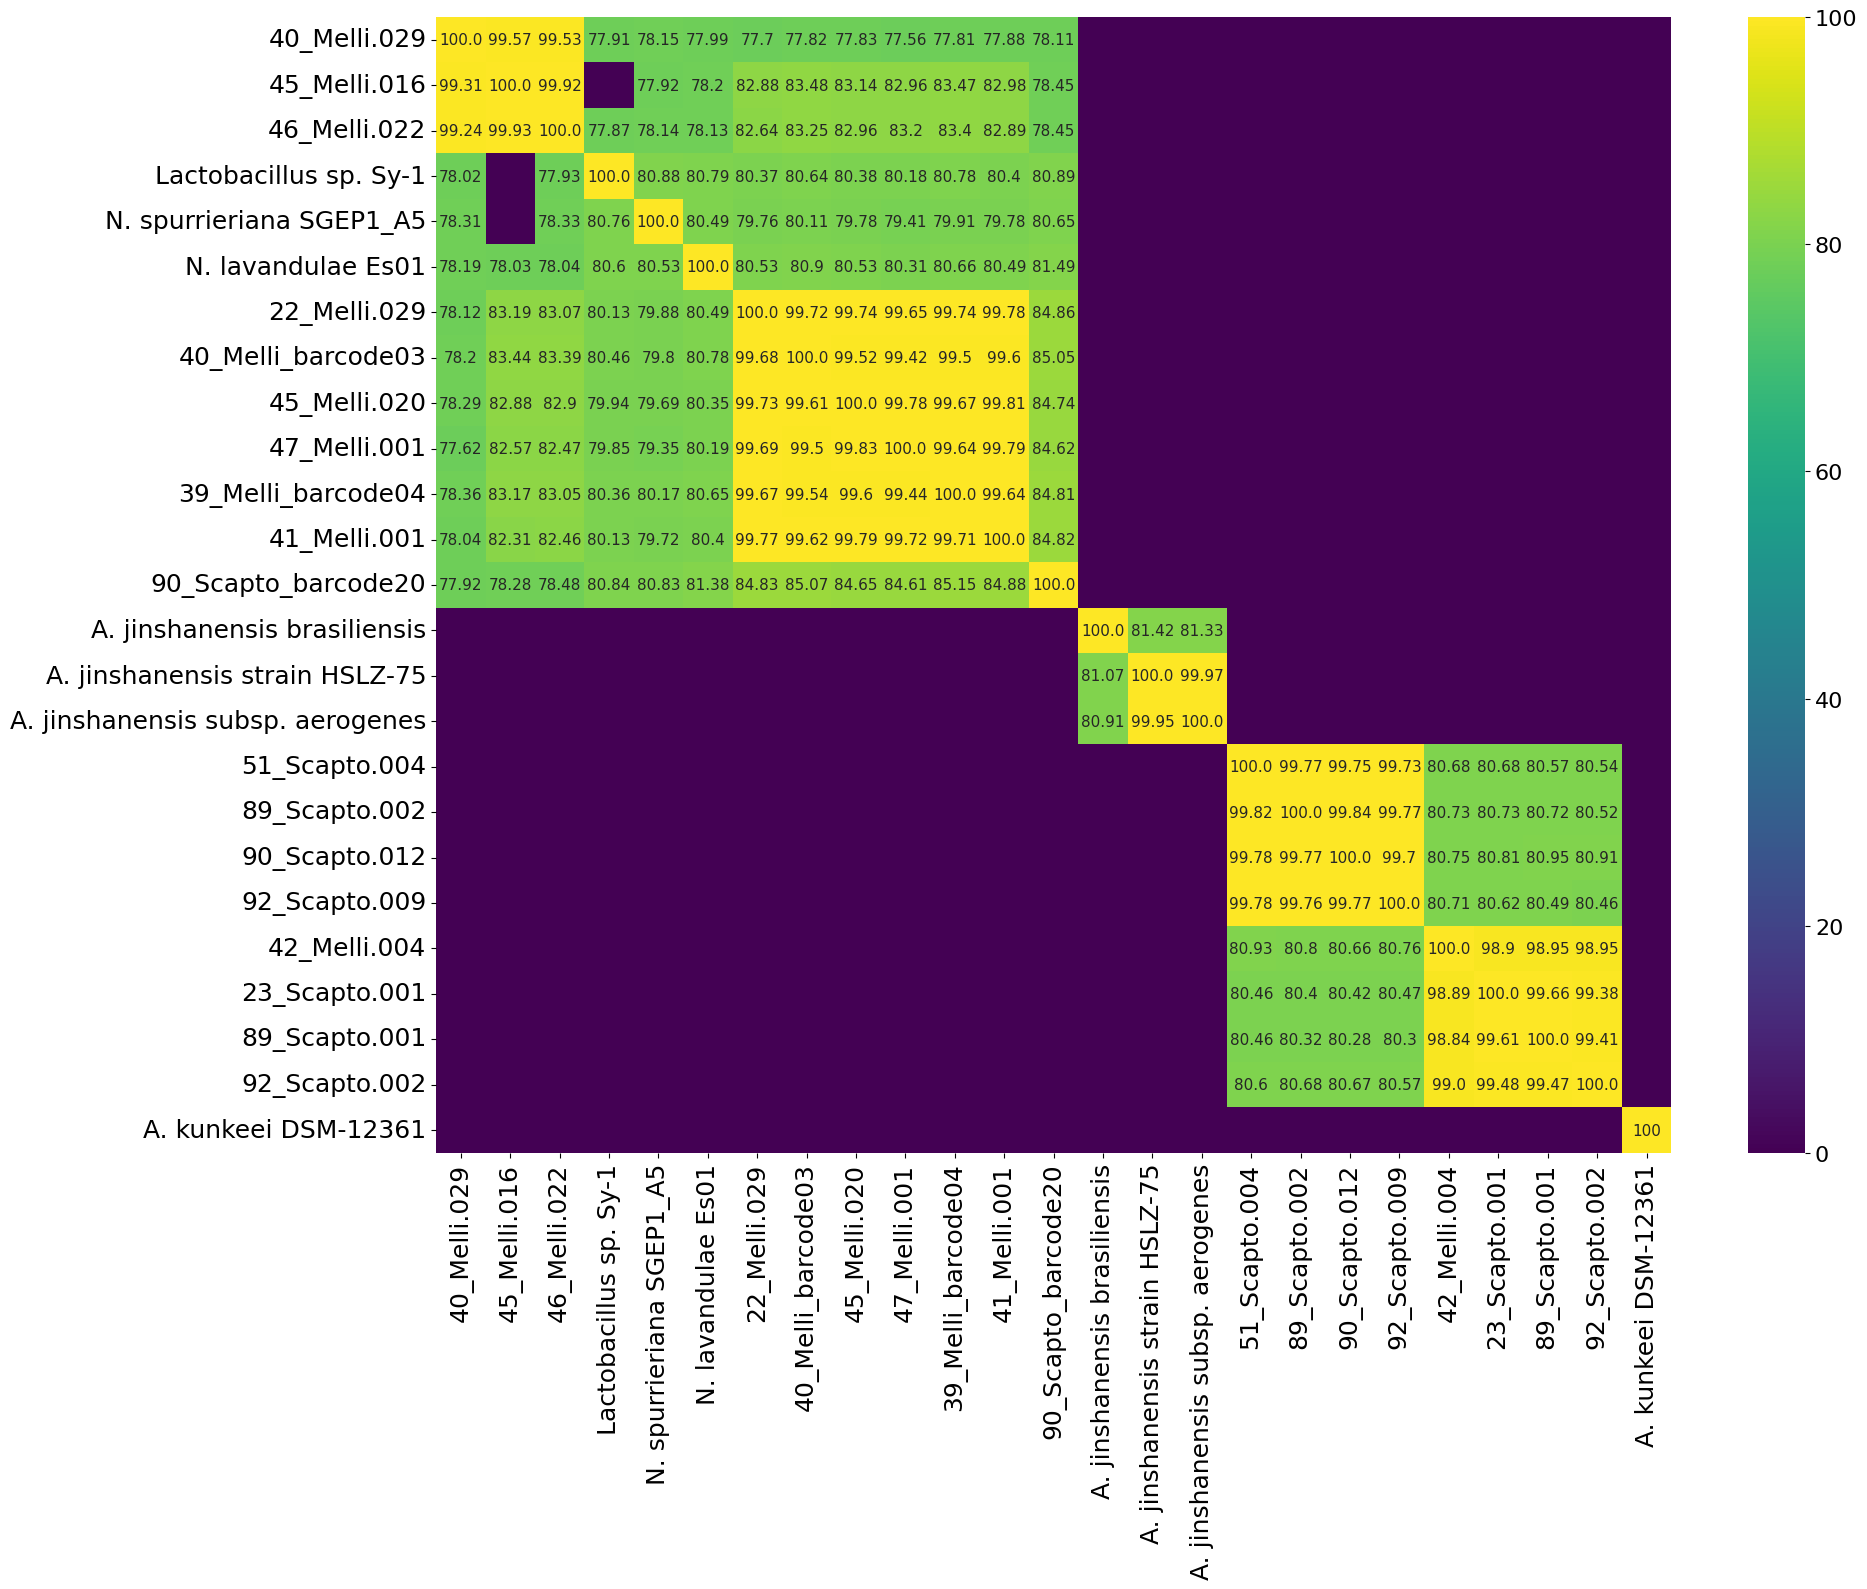

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

annot = matriz_ani.round(2).astype(str)
annot[matriz_ani == 0] = ""

# Figure size
plt.figure(figsize=(20, 16))

# Heatmap with seaborn
ax=sns.heatmap(matriz_ani, annot=annot, fmt="", cmap="viridis", cbar=True, annot_kws={"size": 11})

# Titles and legends
plt.title("", fontsize=16)
plt.xlabel("", fontsize=18)
plt.ylabel("", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
# Show the heatmap
plt.tight_layout()
# save into a svg
plt.savefig("/home/haydeeperuyero/FastANI/miel_ani_aai_caai/heatmap_ANI.svg", format="svg")
plt.show()

# Métricas

In [17]:
# Define groups
groups = {
    "Clade_1": [0, 1,2],
    "Clade_2-barcode20": [6,7,8,9,10,11],
    "Clade_2+barcode20": [6,7,8,9,10,11,12],
    "Clade_3": [16,17,18,19],
    "Clade_4": [20,21,22,23],
    "Nicoliela+Sp1":[3,4,5],
    "Nicoliela":[4,5],
    "Acetilactobacillus":[13,14,15]
}

In [18]:
import numpy as np
import pandas as pd
from itertools import combinations
# Compute mean, std and var
results_within = {}
for group_name, indices in groups.items():
    submatrix = matriz_ani.iloc[indices, indices]
    results_within[group_name] = {
        "mean": submatrix.values.mean(),
        "std_dev": submatrix.values.std(),
        "var": submatrix.values.var()
    }

# Compute the mean, std and var between groups
results_between = {}
for (group_name_1, indices_1), (group_name_2, indices_2) in combinations(groups.items(), 2):
    submatrix = matriz_ani.iloc[indices_1, indices_2]
    key = f"{group_name_1} vs {group_name_2}"
    results_between[key] = {
        "mean": submatrix.values.mean(),
        "std_dev": submatrix.values.std(),
        "var": submatrix.values.var()
    }

# MShow the results
print("The mean, std and var in groups:")
print(pd.DataFrame(results_within).T)

print("\nThe mean, std and var between groupss:")
print(pd.DataFrame(results_between).T)

The mean, std and var in groups:
                         mean   std_dev        var
Clade_1             99.720689  0.295038   0.087047
Clade_2-barcode20   99.719806  0.160328   0.025705
Clade_2+barcode20   96.081582  6.403951  41.010591
Clade_3             99.827288  0.104418   0.010903
Clade_4             99.409369  0.428762   0.183837
Nicoliela+Sp1       87.117333  9.110172  82.995235
Nicoliela           90.254925  9.745084  94.966663
Acetilactobacillus  91.627600  9.343540  87.301732

The mean, std and var between groupss:
                                              mean    std_dev         var
Clade_1 vs Clade_2-barcode20             81.325850   2.525703    6.379175
Clade_1 vs Clade_2+barcode20             80.898400   2.562759    6.567735
Clade_1 vs Clade_3                        0.000000   0.000000    0.000000
Clade_1 vs Clade_4                        0.000000   0.000000    0.000000
Clade_1 vs Nicoliela+Sp1                 69.367044  24.525221  601.486468
Clade_1 vs Nicoliela    

In [14]:
import sys
print(sys.version)

3.9.19 (main, May  6 2024, 19:43:03) 
[GCC 11.2.0]


In [15]:
import seaborn
print(seaborn.__version__)

0.13.2


In [16]:
import matplotlib
print(matplotlib.__version__)

3.9.0
